# Coupling of a Particle Model to a Reactor Model

This notebook demonstrates a generalized approach to coupling a reactor model with a particle model, applicable in various simulation scenarios.

## Implementation Notes

- The code is modular and supports multi-component systems.
- Boundary conditions are flexible and can be customized for the reactor model.
- The framework is designed for extensibility, allowing users to implement custom kinetics, geometries, and coupling strategies.
- The notebook includes plotting utilities and example usage for both standalone and coupled simulations.

Refer to the docstrings in each class and function for further details on usage and customization.

## Overview of the Model Classes

This notebook contains the following main classes:

- **DiffusionConvectionReactionNonLinear**: A 1D model for plug flow reactors with convection, diffusion, and nonlinear reaction kinetics. Supports both steady-state and transient solutions, and can be flexibly coupled to other models via a user-supplied kinetics function.

- **Kinetics**: A simple class for first-order reaction kinetics, providing both the rate and the Jacobian for use in nonlinear solvers.

- **ParticleModel**: A general 1D (or quasi-1D) reaction-diffusion model for a particle, supporting arbitrary geometry and user-supplied nonlinear kinetics. Designed for both steady-state and transient solutions, and can be used for multi-component systems.

Each class is documented with detailed docstrings, and the notebook demonstrates how to use these classes for both standalone and coupled simulations.

In [1]:
import math
import numpy as np
from matplotlib import pyplot as plt
import scipy.sparse.linalg as sla
from scipy.sparse import csc_array
from pymrm import construct_grad, construct_convflux_upwind, interp_cntr_to_stagg_tvd, minmod, construct_div, newton, construct_coefficient_matrix, NumJac, non_uniform_grid, update_csc_array_indices, construct_convflux_upwind, construct_interface_matrices

In [2]:
class DiffusionConvectionReactionNonLinear:
    """
    1D diffusion-convection-reaction model with optional nonlinear kinetics.

    This class models a 1D domain with convection, diffusion, and nonlinear reaction kinetics.
    It supports both steady-state and transient solutions, and can be flexibly coupled to
    other models via the g_kinetics argument.

    Parameters
    ----------
    shape : tuple
        Shape of the concentration field (number of grid points, number of components).
    axis : int, optional
        Axis along which the diffusion and convection occur (default: 0).
    g_kinetics : callable, optional
        Function returning (reaction residual, jacobian) for the nonlinear kinetics.
    L : float, optional
        Length of the domain (default: 1.0).
    v : float or array, optional
        Velocity (default: 1.0).
    D : float or array, optional
        Diffusion coefficient (default: 0.0).
    c_0 : float or array, optional
        Initial concentration (default: 0.0).
    bc : tuple, optional
        Boundary conditions for the domain.
    dt : float, optional
        Time step size (default: np.inf for steady-state).
    freq_out : int, optional
        Output frequency for time stepping (default: 10).

    Attributes
    ----------
    c : ndarray
        Concentration field.
    c_old : ndarray
        Previous concentration field (for time stepping).
    z_f, z_c : ndarray
        Face and center grid points.
    jac_const : sparse matrix
        Constant part of the Jacobian.
    g_const : ndarray
        Constant part of the residual.
    """

    def __init__(self, shape, axis = 0,  g_kinetics=None, L = 1.0, v = 1.0, D = 0.0, c_0 = 0.0, bc = None, dt=np.inf, freq_out=10, callback_newton = None):
        # Initialize model parameters
        self.shape = shape # Shape of the concentration field
        self.axis = axis  # Axis along which the diffusion and convection occur
        self.v = np.asarray(v)  # Velocity
        self.D = np.asarray(D)  # Diffusion coefficient
        self.L = L  # Domain length
        self.bc = bc # Boundary conditions
        self.dt = dt  # Time step size
        self.freq_out = freq_out  # Frequency of output (e.g., every 10 steps)
        self.z_f = np.linspace(0, self.L, self.shape[self.axis] + 1)  # Cell-face positions
        self.z_c = 0.5 * (self.z_f[:-1] + self.z_f[1:])  # Cell-centered grid points
        self.init_field(c_0)  # Initialize the concentration field
        self.init_jac()  # Initialize the Jacobian matrix
        self.g_kinetics = g_kinetics  # Kinetics function
        self.callback_newton = callback_newton  # Callback function for Newton's method

    def init_field(self, c_0=0):
        """
        Initialize the concentration field with a uniform value.

        Parameters
        ----------
        c_0 : float or array, optional
            Initial concentration value(s).
        """
        # Initialize the concentration field with a uniform value (default is 0.0)
        c = np.asarray(c_0)
        shape = (1,) * (len(self.shape) - c.ndim) + c.shape
        c = c.reshape(shape)
        self.c = np.broadcast_to(c, self.shape).copy()
        self.c_old = self.c.copy()  # Store the old concentration field for time-stepping
    
    def init_jac(self):
        """
        Construct the Jacobian matrix and constant terms for the system.
        """
        # Construct the Jacobian matrix and constant terms for the system
        grad_mat, grad_bc  = construct_grad(self.shape, self.z_f, self.z_c, self.bc, axis=self.axis)  # Gradient operator
        self.div_mat = construct_div(self.c.shape, self.z_f, axis=self.axis)  # Divergence operator
        diff_mat = construct_coefficient_matrix(self.D, shape = self.shape, axis=self.axis)  # Diffusion coefficient matrix
        convflux_mat, convflux_bc = construct_convflux_upwind(self.shape, self.z_f, self.z_c, self.bc, axis=self.axis, v = self.v)  # Convection flux operator 
        jac_convdiff = self.div_mat @ (convflux_mat -diff_mat @ grad_mat) #- div_v_mat # Diffusion term
        self.g_const = self.div_mat @ (convflux_bc -diff_mat @ grad_bc)  # Boundary condition forcing term
        jac_accum = construct_coefficient_matrix(1.0/self.dt, shape = self.shape)  # Accumulation term

        self.jac_const = jac_accum + jac_convdiff  # Total Jacobian matrix

    def g(self, c):
        """
        Compute the residual vector and Jacobian matrix for the current time step.

        Parameters
        ----------
        c : array
            Current concentration values.

        Returns
        -------
        tuple
            Residual vector and Jacobian matrix.
        """
        # Compute the residual vector and Jacobian matrix for the current time step
        c_f, dc_f = interp_cntr_to_stagg_tvd(self.c, self.z_f, self.z_c, self.bc, self.v, minmod)
        dg_conv = self.div_mat @ (self.v * dc_f).reshape((-1, 1))
        g = self.g_const + self.jac_const @ c.reshape((-1, 1)) + dg_conv- self.c_old.reshape((-1, 1)) / self.dt
        if self.g_kinetics is not None:
            g_react, jac_react = self.g_kinetics(c)
            g -= g_react.reshape((-1, 1))
            jac = self.jac_const - jac_react
        else:
            jac = self.jac_const            
        return g, jac

    def step_dt(self):
        """
        Store the current concentration as the previous value for time stepping.
        """
        self.c_old = self.c.copy()

    def solve(self):
        """
        Solve the system using Newton's method.
        """
        result = newton(lambda c: self.g(c), self.c, maxfev=10, callback=self.callback_newton)
        self.c[...] = result.x.reshape((self.c.shape))  # Update the concentration field

In [3]:
class Kinetics:
    """
    Simple kinetics class for single-component first-order reactions.

    This class provides a rate function and a method to compute the Jacobian
    for a first-order reaction of the form: rate = -k * c.

    Parameters
    ----------
    shape : tuple
        Shape of the concentration field.
    k : float
        Reaction rate constant.

    Methods
    -------
    rate(c)
        Returns the reaction rate for concentration c.
    compute_g(c)
        Returns (reaction residual, jacobian) for use in nonlinear solvers.
    """

    def __init__(self, shape, k):
        """
        Initialize the Kinetics class.

        Parameters
        ----------
        shape : tuple
            Shape of the concentration field.
        k : float
            Reaction rate constant.
        """
        # Initialize the kinetics function
        self.shape = shape
        self.k = k
        self.numjac = NumJac(shape)

    def rate(self, c):
        """
        Compute the reaction rate for a given concentration.

        Parameters
        ----------
        c : array
            Concentration values.

        Returns
        -------
        array
            Reaction rate.
        """
        # Define the rate of reaction
        rate = np.zeros(self.shape)
        r = self.k * c[...,0]
        rate[...,0] = -r
        return rate

    def compute_g(self, c):
        """
        Compute the residual and Jacobian for the reaction kinetics.

        Parameters
        ----------
        c : array
            Concentration values.

        Returns
        -------
        tuple
            Residual and Jacobian.
        """
        return self.numjac(self.rate, c)


## Example: Steady-State Solution of a Plug Flow Reactor

This example demonstrates how to compute a steady-state solution for a plug flow reactor using first-order kinetics. The reactor is modeled as a 1D domain with convection, diffusion, and nonlinear reaction kinetics.

The model is configured to simulate the reaction-diffusion process under steady-state conditions, utilizing the kinetic parameters and boundary conditions defined in the code.

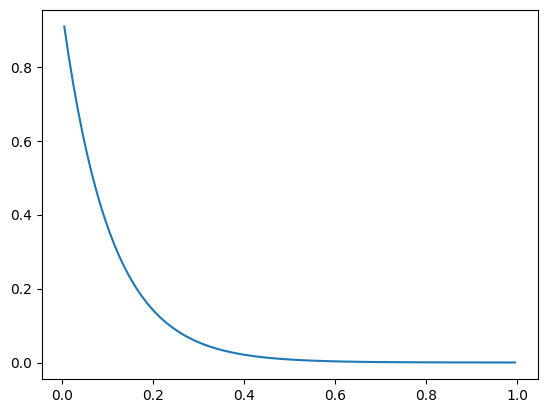

In [4]:
shape = (100,1)
kinetics = Kinetics(shape, 10.0)

bc = ({'a':0, 'b': 1, 'd': 1}, {'a':1, 'b': 0, 'd': 0})
reactor_model = DiffusionConvectionReactionNonLinear(shape, bc = bc, g_kinetics = kinetics.compute_g)
reactor_model.solve()

plt.plot(reactor_model.z_c, reactor_model.c[:,0])


In [21]:
class ParticleModel:
    """
    General 1D (or quasi-1D) reaction-diffusion model for a particle.

    This class models a particle with arbitrary geometry and user-supplied
    nonlinear kinetics. It supports both steady-state and transient solutions,
    and can be used for multi-component systems.

    Parameters
    ----------
    shape : tuple
        Shape of the concentration field (number of grid points, number of components).
    axis : int, optional
        Axis along which the diffusion occurs (default: -2).
    c_0 : float or array, optional
        Initial concentration (default: 0.0).
    R : float, optional
        Particle radius (default: 1.0).
    D : float or array, optional
        Diffusion coefficient(s) (default: 1.0).
    nu : int, optional
        Geometric factor for divergence operator (default: 2).
    dt : float, optional
        Time step size (default: np.inf for steady-state).
    g_kinetics : callable, optional
        Function returning (reaction residual, jacobian) for the nonlinear kinetics.

    Attributes
    ----------
    c : ndarray
        Concentration field.
    c_old : ndarray
        Previous concentration field (for time stepping).
    r_f, r_c : ndarray
        Face and center grid points.
    jac_diff : sparse matrix
        Diffusion Jacobian.
    jac_diff_bc : sparse matrix
        Boundary condition Jacobian.
    r_apparent_mat, r_apparent_bc_mat : ndarray
        Matrices for computing apparent reaction rates.
    numjac : NumJac
        Numerical Jacobian helper for nonlinear kinetics.

    Methods
    -------
    init_field(c_0)
        Initialize the concentration field.
    init_jac()
        Construct the Jacobian matrix and constant terms for the system.
    g(c, c_b)
        Returns (residual, jacobian) for the current time step.
    step_time()
        Updates c_old for time stepping.
    apparent_reaction_rate(c_b, solve=True, compute_jac=False)
        Computes the apparent reaction rate for given boundary concentrations.
    schur_init(c=None)
        Store the current concentration for Schur complement updates.
    schur_post_step(c)
        Update the concentration after a Schur complement step.
    """

    def __init__(self, shape, axis = -2, c_0 = 0.0, R=1.0, D=1.0, nu=2, dt=np.inf, g_kinetics=None):
        """
        Initialize the diffusion-reaction model.

        Parameters
        ----------
        shape : tuple
            Shape of the concentration field (number of grid points, number of components).
        axis : int, optional
            Axis along which the diffusion occurs (default: -2).
        c_0 : float or array, optional
            Initial concentration (default: 0.0).
        R : float, optional
            Particle radius (default: 1.0).
        D : float or array, optional
            Diffusion coefficient(s) (default: 1.0).
        nu : int, optional
            Geometric factor for divergence operator (default: 2).
        dt : float, optional
            Time step size (default: np.inf for steady-state).
        g_kinetics : callable, optional
            Function returning (reaction residual, jacobian) for the nonlinear kinetics.
        """
        # Initialize model parameters
        self.shape = shape  # Shape of the concentration field
        if axis < 0:
            self.axis = len(shape)+ axis  # Axis along which the diffusion occurs
        else:
            self.axis = axis
        self.shape_d = tuple(1 if i == self.axis else s for i, s in enumerate(self.shape))
        self.shape_c_b = tuple(s for i, s in enumerate(shape) if i != self.axis)
        self.nu = nu  # Geometric factor for divergence operator
        self.bc = ({'a': 1, 'b': 0, 'd': 0},  # Left boundary conditions
                   {'a': 0, 'b': 1, 'd': 1})  # Right boundary conditions
        self.D = D  # Diffusion coefficients
        self.R = R  # Particle radius
        self.dt = dt  # Time step size

        # Generate a non-uniform grid for cell-face positions
        dr_large = 0.1 * self.R
        self.r_f = non_uniform_grid(0, self.R, self.shape[self.axis] + 1, dr_large, 0.75)
        self.r_c = 0.5 * (self.r_f[:-1] + self.r_f[1:])

        # Initialize the concentration field and Jacobian matrix
        self.init_field(c_0)
        if (self.dt == np.inf):
            self.c_old = None
        else:
            self.c_old = np.zeros_like(self.c)
        self.init_jac()
        self.g_kinetics = g_kinetics

    def init_field(self, c_0=0.0):
        """
        Initialize the concentration field with a uniform value.

        Parameters
        ----------
        c_0 : float or array, optional
            Initial concentration value(s).
        """
        # Initialize the concentration field with a uniform value (default is 0.0)
        c = np.asarray(c_0)
        shape = (1,) * (len(self.shape) - c.ndim) + c.shape  # Ensure c
        c = c.reshape(shape)  # Reshape c to 2D
        self.c = np.broadcast_to(c, self.shape).copy()  # Broadcast c to the correct shape

    def init_jac(self):
        """
        Construct the Jacobian matrix and constant terms for the system.
        """
        # Construct the Jacobian matrix and constant terms for the system
        grad_mat, _, grad_bc_mat = construct_grad(self.shape, self.r_f, self.r_c, self.bc, axis = self.axis, shapes_d=(None,self.shape_d))
        div_mat = construct_div(self.shape, self.r_f, nu=self.nu, axis = self.axis)

        # Construct diffusion coefficient matrix
        D = np.asarray(self.D)
        if D.ndim == 0:
            D = D[None]
        shape_D = (1,)*(len(self.shape)-D.ndim) + D.shape
        D = D.reshape(shape_D)
        diff_mat = construct_coefficient_matrix(D, shape=self.shape, axis = self.axis)

        # Compute flux terms
        flux_mat = -diff_mat @ grad_mat
        flux_bc_mat = -diff_mat @ grad_bc_mat

        # Compute Jacobian of diffusion term and boundary forcing term
        self.jac_diff = div_mat @ flux_mat
        self.jac_diff_bc = div_mat @ flux_bc_mat
        self.jac_diff_bc_array = self.jac_diff_bc.toarray()

        # Accumulation term for time-dependent problems
        self.jac_accum = construct_coefficient_matrix(1.0 / self.dt, shape=self.shape)

        # Apparent reaction rate terms
        # Use correct indices for the last face (right boundary)
        shape_f_t = (math.prod(self.shape[0:self.axis]), self.shape[self.axis]+1, math.prod(self.shape[self.axis+1:]))
        i_col = (shape_f_t[2]*shape_f_t[1]*np.arange(shape_f_t[0]).reshape((-1, 1)) + shape_f_t[2]*self.shape[self.axis] + np.arange(shape_f_t[2]).reshape((1, -1))).ravel()
        self.r_apparent_mat = ((self.nu + 1) / self.R) * flux_mat[i_col, :]
        self.r_apparent_bc_mat = ((self.nu + 1) / self.R) * flux_bc_mat[i_col, :]

        # Numerical Jacobian for reaction terms
        self.numjac = NumJac(self.shape)

    def g(self, c, c_b):
        """
        Compute the residual vector and Jacobian matrix for the current time step.

        Parameters
        ----------
        c : array
            Current concentration values.
        c_b : array
            Boundary concentration values.

        Returns
        -------
        tuple
            Residual vector and Jacobian matrix.
        """
        # Compute the residual vector and Jacobian matrix for the current time step
        c_b = np.asarray(c_b)
        g = self.jac_diff_bc @ c_b.reshape((-1,1)) + self.jac_diff @ c.reshape((-1, 1))
        jac = self.jac_diff
        if self.c_old is not None:
            g_accum  = self.jac_accum @ (c.reshape((-1, 1)) - self.c_old.reshape((-1, 1)))
            g += g_accum
            jac += self.jac_accum
        if self.g_kinetics is not None:
            g_react, jac_react = self.g_kinetics(c)
            g -= g_react.reshape((-1, 1))
            jac -= jac_react
        return g, jac

    def step_time(self):
        """
        Store the current concentration as the previous value for time stepping.
        """
        self.c_old = self.c.copy()

    def apparent_reaction_rate(self, c_b, solve = False, compute_jac = False):
        """
        Compute the apparent reaction rate based on the current concentration field.

        Parameters
        ----------
        c_b : array
            Boundary concentration values.
        solve : bool, optional
            If True, solve for the steady-state concentration before computing the rate.
        compute_jac : bool, optional
            If True, also compute the Jacobian of the apparent reaction rate.

        Returns
        -------
        array or tuple
            Apparent reaction rates for each component, and optionally the Jacobian.
        """ 
        if solve and not compute_jac:
            result = newton(lambda c: self.g(c, c_b), self.c, maxfev=10)
            self.c[...] = result.x.reshape(self.shape)

        c_vec = self.c.reshape((-1, 1))
        c_b_vec = np.asarray(c_b).reshape((-1, 1))
        if compute_jac:
            self.c_b_prev = c_b.copy()
            g, jac_ss = self.g(self.c, c_b)
            jac_ss_lu = sla.splu(jac_ss)
            dc = -jac_ss_lu.solve(g)
            c_vec[...] += dc
            r_apparent = self.r_apparent_mat @ c_vec + self.r_apparent_bc_mat @ c_b_vec
            # The Jacobian calculation here is a placeholder; adjust as needed for your application
            self.jac_sf_schur = csc_array(jac_ss_lu.solve(self.jac_diff_bc_array))
            jac = -self.r_apparent_mat @ self.jac_sf_schur + self.r_apparent_bc_mat
            return r_apparent.reshape(self.shape_c_b), jac
        else:
            r_apparent = self.r_apparent_mat @ c_vec + self.r_apparent_bc_mat @ c_b_vec
            return r_apparent.reshape((self.shape_c_b))
            
    def schur_post_step(self, c_b, g):
        """
        Update the concentration after a Schur complement step.

        Parameters
        ----------
        c : array
            Updated concentration.
        """
        dc_b = c_b - self.c_b_prev
        c_vec = self.c.reshape((-1, 1))
        c_vec[...] -= self.jac_sf_schur @ dc_b
        self.c_b_prev = c_b.copy()
        

## Example: Steady-State Solution of the Particle Model

This example demonstrates how to compute a steady-state solution for a particle model using user-defined kinetics. The particle is modeled as a 1D domain (e.g., spherical or slab geometry) with diffusion and nonlinear reaction kinetics.

The model is configured to simulate the reaction-diffusion process within a particle under steady-state conditions, utilizing the predefined kinetic parameters.

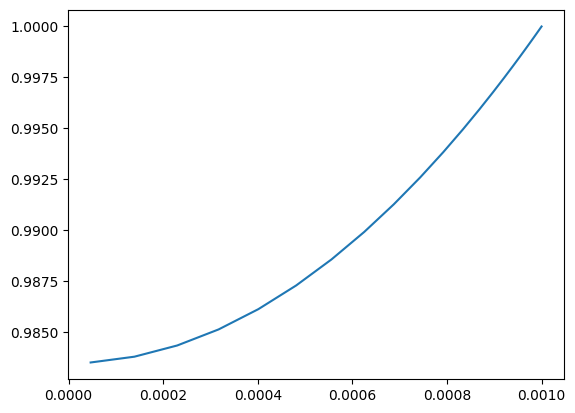

In [22]:
shape_pm = (30,1)
c_b = np.asarray([[1.0]])

kinetics_pm = Kinetics(shape_pm, 1.0)

particle_model = ParticleModel(shape_pm, R=1e-3, D=1e-5, nu=2,  g_kinetics = kinetics_pm.compute_g)
r_app, jac_app = particle_model.apparent_reaction_rate(c_b, compute_jac=True)
plt.plot(particle_model.r_c, particle_model.c[:,0])

## Example: Steady-State Solution of the Particle Model

This example demonstrates how to compute a steady-state solution for a particle model using user-defined kinetics. The particle is modeled as a 1D domain (e.g., spherical or slab geometry) with diffusion and nonlinear reaction kinetics.

The model is configured to simulate the reaction-diffusion process within a particle under steady-state conditions, utilizing the predefined kinetic parameters.

## Explicit Coupling and 'black-box' Coupling

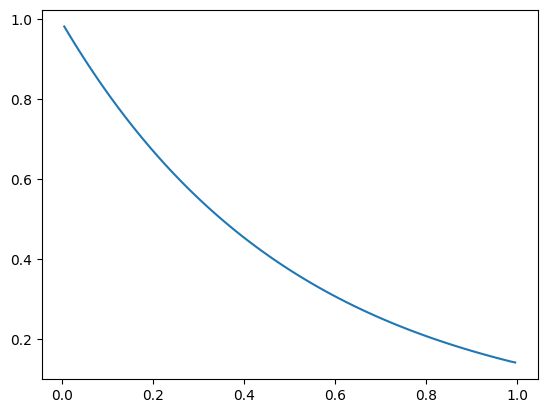

In [ ]:
shape = (100,1)
shape_pm = shape[0:-1] + (30,) + shape[-1:]
kinetics_pm = Kinetics(shape_pm, 10.0)

particle_model = ParticleModel(shape_pm, R=1e-3, D=1e-5, g_kinetics = kinetics_pm.compute_g)
kinetics_app = lambda c_b: particle_model.apparent_reaction_rate(c_b, solve=True)

jac_kinetics_app = csc_array((math.prod(shape), math.prod(shape)))
g_kinetics_app = lambda c: (particle_model.apparent_reaction_rate(c, solve=True), jac_kinetics_app)

#numjac = NumJac(shape)
#g_kinetics_app = lambda c: numjac(kinetics_app, c)

bc = ({'a':0, 'b': 1, 'd': 1}, {'a':1, 'b': 0, 'd': 0})
reactor_model = DiffusionConvectionReactionNonLinear(shape, bc = bc, g_kinetics = g_kinetics_app)
reactor_model.solve()

plt.plot(reactor_model.z_c, reactor_model.c[:,0])

## Coupling with Schur complement

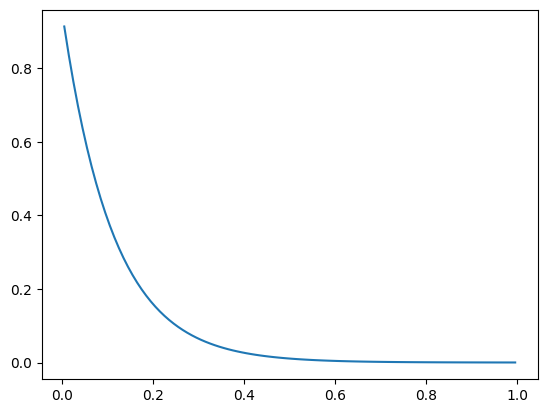

In [26]:
shape = (100,1)
shape_pm = shape[0:-1] + (30,) + shape[-1:]
kinetics_pm = Kinetics(shape_pm, 10.0)
particle_model = ParticleModel(shape_pm, R=1e-3, D=1e-5, g_kinetics = kinetics_pm.compute_g)

g_kinetics_app = lambda c_b: particle_model.apparent_reaction_rate(c_b, solve=False, compute_jac=True)
bc = ({'a':0, 'b': 1, 'd': 1}, {'a':1, 'b': 0, 'd': 0})
reactor_model = DiffusionConvectionReactionNonLinear(shape, bc = bc, g_kinetics = g_kinetics_app, callback_newton = particle_model.schur_post_step)
reactor_model.solve()

plt.plot(reactor_model.z_c, reactor_model.c[:,0])